# Parte 2 &mdash; Trilha B: Embeddings Discriminativos

**Objetivo da entrega.** Manter o *encoder&ndash;decoder* da Parte 1 (a mesma U-Net) e
trocar apenas **o que a rede prev&ecirc;**. A apresenta&ccedil;&atilde;o precisa mostrar, com as
**mesmas m&eacute;tricas da Parte 1 lado a lado com a baseline**, por que essa
representa&ccedil;&atilde;o resolve o problema que limiar + componentes conexos n&atilde;o resolve.

## Por que a Trilha B, e n&atilde;o a A ou a C

As tr&ecirc;s trilhas resolvem o mesmo problema, mas **A e C carregam uma suposi&ccedil;&atilde;o
geom&eacute;trica** que quebra quando um objeto est&aacute; contido em outro:

| Trilha | Suposi&ccedil;&atilde;o impl&iacute;cita | O que acontece com objetos aninhados |
|---|---|---|
| **A** &mdash; fronteiras + watershed | a fronteira entre inst&acirc;ncias separa regi&otilde;es **vizinhas** | a fronteira do objeto interno &eacute; uma curva **fechada dentro** do externo; o watershed inunda a partir dos marcadores e o objeto interno vira um buraco, n&atilde;o uma inst&acirc;ncia |
| **C** &mdash; centro + offsets | cada pixel tem **um** centro, e centros distintos ficam distantes | continente e contido t&ecirc;m centr&oacute;ides quase coincidentes &rarr; os dois picos do heatmap se fundem e o campo de offsets fica amb&iacute;guo (o mesmo vetor serve para os dois) |
| **B** &mdash; embeddings | **nenhuma** &mdash; identidade &eacute; um vetor aprendido por pixel | dois objetos conc&ecirc;ntricos recebem simplesmente dois *clusters* distantes no espa&ccedil;o de embedding; a posi&ccedil;&atilde;o no plano da imagem n&atilde;o entra na conta |

&Eacute; esse desacoplamento entre **identidade** e **geometria** que motiva a troca.

## O que a rede prev&ecirc;

| Cabe&ccedil;a | Sa&iacute;da | Alvo | Perda |
|---|---|---|---|
| `foreground` | `[N,1,H,W]` | m&aacute;scara bin&aacute;ria (uni&atilde;o das inst&acirc;ncias) | BCE **ponderada** (`pos_weight`) |
| `embedding`  | `[N,D,H,W]` | o pr&oacute;prio mapa de inst&acirc;ncias | **discriminativa** (vari&acirc;ncia + dist&acirc;ncia + regulariza&ccedil;&atilde;o) |

A perda discriminativa (De Brabandere et al., 2017) tem tr&ecirc;s termos:

* **vari&acirc;ncia** &mdash; puxa cada pixel para o centr&oacute;ide do embedding da sua pr&oacute;pria
  inst&acirc;ncia, com margem `delta_v` (dentro da margem, gradiente zero);
* **dist&acirc;ncia** &mdash; empurra centr&oacute;ides de inst&acirc;ncias diferentes, com margem `2*delta_d`;
* **regulariza&ccedil;&atilde;o** &mdash; segura os centr&oacute;ides perto da origem.

## Respostas &agrave;s perguntas do enunciado

* **Qual D?** `D = 8`. Precisa comportar &asymp;&nbsp;100 n&uacute;cleos por imagem como *clusters*
  separ&aacute;veis; 2&ndash;3 dimens&otilde;es ficam apertadas, e acima de ~16 o *clustering* fica
  mais lento sem ganho vis&iacute;vel neste dataset.
* **Quais margens?** `delta_v = 0.5` e `delta_d = 1.5`. A condi&ccedil;&atilde;o que importa &eacute;
  **`delta_d > 2*delta_v`**: com ela, uma bola de raio `delta_v` em torno de cada
  centr&oacute;ide n&atilde;o intersecta a de nenhum outro, ent&atilde;o o *clustering* &eacute; garantido
  se a perda chegar a zero.
* **O clustering na infer&ecirc;ncia precisa saber o n&uacute;mero de objetos?** **N&atilde;o.** Usamos
  **mean-shift de banda fixa** (`bandwidth = delta_v`), que acha os modos
  sequencialmente. `k-means` precisaria de `k`, o que seria in&uacute;til numa tarefa cujo
  objetivo &eacute; justamente **contar** os n&uacute;cleos.
* **Por que mean-shift e n&atilde;o DBSCAN?** Medimos os dois (o `cluster_embeddings`
  aceita `method="dbscan"`). Os pixels da **borda** entre duas inst&acirc;ncias t&ecirc;m
  embeddings intermedi&aacute;rios e formam um **filamento cont&iacute;nuo** ligando os dois
  *clusters*. DBSCAN &eacute; conectividade **transitiva** por densidade, ent&atilde;o ele
  atravessa o filamento e funde as inst&acirc;ncias. No caso aninhado o filamento &eacute; um
  **anel inteiro**, e o DBSCAN devolve **1** *cluster* para qualquer `eps` testado
  (0,3 a 1,0). A bola de raio fixo em torno de um modo n&atilde;o tem transitividade e
  separa corretamente.

## Decodifica&ccedil;&atilde;o

1. **Baseline (Parte 1):** `foreground > t` &rarr; `scipy.ndimage.label` (componentes conexos).
   N&uacute;cleos encostados viram **um** componente.
2. **Trilha B:** `foreground > t` &rarr; mean-shift sobre os embeddings dos pixels de
   foreground, e cada pixel vai para o modo mais pr&oacute;ximo. N&uacute;cleos encostados t&ecirc;m
   embeddings distantes, ent&atilde;o caem em *clusters* diferentes mesmo colados no
   plano da imagem.

A compara&ccedil;&atilde;o abaixo isola exatamente esse efeito: **mesma rede, mesma m&aacute;scara de
foreground, s&oacute; muda o decodificador.**

**Regra de matching (todas as m&eacute;tricas de inst&acirc;ncia):** guloso por IoU decrescente;
cada predi&ccedil;&atilde;o casa com no m&aacute;ximo um ground truth e vice-versa
(`src/nn/metrics.py::match_instances`).

In [8]:
# ============================================================
# IMPORTS
# ============================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

from PIL import Image
import torchvision.transforms.functional as TF

from scipy.spatial.distance import cdist

from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform

from src.nn.models import UNet
from src.nn.optimizers import create_optimizer

from src.nn.loss import discriminative_loss

from src.nn.targets import (
    instance_map_to_embedding_targets,
    cluster_embeddings,
)

from src.nn.metrics import (
    binary_iou_dice,
    instance_scores,
    connected_components,
    count_tp_fp_fn,
    mean_average_precision,
)

In [ ]:
# ============================================================
# CONFIGURACOES
# ============================================================

SEED = 67

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# Representacao / perdas
# ------------------------------------------------------------

IMAGE_SIZE          = (128, 128)   # mesmo tamanho da Parte 1
EMBEDDING_DIM       = 8           # D
DELTA_V             = 0.3          # margem de atracao (raio do cluster)
DELTA_D             = 1.2          # margem de repulsao (delta_d > 2*delta_v)
ALPHA, BETA, GAMMA  = 0.01, 0.01, 0.001
EMBEDDING_WEIGHT    = 1.1          # peso da perda discriminativa no total
FG_POS_WEIGHT       = 3.0          # nucleo e minoria -> BCE ponderada
MIN_INSTANCE_PIXELS = 4            # descarta instancias que sumiram no resize

# ------------------------------------------------------------
# Decodificacao  (ajuste pelo DIAGNOSTICO antes do eval caro)
# ------------------------------------------------------------

FG_THRESHOLD         = 0.3        # limiar do foreground
CLUSTER_METHOD       = "dbscan"  # "mean_shift" (padrao) ou "dbscan"
CLUSTER_BANDWIDTH    = 0.1       # raio da bola = raio garantido pela perda
CLUSTER_MERGE_RADIUS = DELTA_D     # funde modos espurios do filamento de borda
MIN_CLUSTER_SIZE     = 10          # descarta instancias minusculas
DBSCAN_EPS           = 0.3         # so usado com CLUSTER_METHOD="dbscan"


NUM_EPOCHS = 10
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

assert DELTA_D > 2 * DELTA_V, "delta_d precisa ser > 2*delta_v para os clusters serem separaveis"

Device: cpu


In [ ]:
class UNetTrilhaB(nn.Module):
    """
    U-Net da Parte 1 com duas cabecas:

        foreground : [N, 1, H, W]              logit
        embedding  : [N, EMBEDDING_DIM, H, W]  vetor por pixel
    """

    def __init__(self, embedding_dim=EMBEDDING_DIM):
        super().__init__()

        base = UNet(num_classes=2)   # backbone identico ao da Parte 1

        self.enc1, self.enc2, self.enc3 = base.enc1, base.enc2, base.enc3
        self.pool = base.pool

        self.up3, self.dec3 = base.up3, base.dec3
        self.up2, self.dec2 = base.up2, base.dec2
        self.up1, self.dec1 = base.up1, base.dec1

        # antes: um unico Conv2d(16, num_classes, 1)
        self.foreground_head = nn.Conv2d(16, 1, kernel_size=1)
        self.embedding_head  = nn.Conv2d(16, embedding_dim, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x); p1 = self.pool(e1)
        e2 = self.enc2(p1); p2 = self.pool(e2)
        e3 = self.enc3(p2); p3 = self.pool(e3)

        d3 = self.dec3(torch.cat([self.up3(p3), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.foreground_head(d1), self.embedding_head(d1)

In [ ]:
def masks_to_list(instance_map):
    """instance_map [H,W] com ids 0..K  ->  lista de mascaras booleanas."""
    ids = np.unique(instance_map)
    ids = ids[ids > 0]
    return [instance_map == i for i in ids]


def resize_gt(gt_bool, size):
    img = Image.fromarray((gt_bool.astype(np.uint8) * 255))
    img = TF.resize(img, size, interpolation=TF.InterpolationMode.NEAREST)
    return np.array(img) > 0


def embedding_separability(embedding, instance_map):
    """
    Mede se a perda discriminativa fez o seu trabalho.

    Devolve (dist. media intra-cluster, menor dist. entre centroides).
    Treino bem-sucedido =>  intra < DELTA_V  e  inter > 2 * DELTA_D.
    """
    ids = np.unique(instance_map)
    ids = ids[ids > 0]
    if len(ids) == 0:
        return np.nan, np.nan

    centroids, intra = [], []
    for i in ids:
        points = embedding[:, instance_map == i].T
        centroid = points.mean(axis=0)
        centroids.append(centroid)
        intra.append(np.linalg.norm(points - centroid, axis=1).mean())

    if len(centroids) < 2:
        return float(np.mean(intra)), np.inf

    d = cdist(np.stack(centroids), np.stack(centroids))
    np.fill_diagonal(d, np.inf)
    return float(np.mean(intra)), float(d.min())


def embedding_to_rgb(embedding, foreground):
    """
    Projeta o embedding D-dimensional em 3 canais (SVD) para visualizar.
    Pixels da mesma instancia devem sair com a mesma cor.
    """
    d, h, w = embedding.shape
    flat = embedding.reshape(d, -1).T
    mask = foreground.reshape(-1)

    rgb = np.zeros((h * w, 3), dtype=np.float32)
    if mask.sum() < 3:
        return rgb.reshape(h, w, 3)

    points = flat[mask]
    centered = points - points.mean(axis=0)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)

    projected = (flat - points.mean(axis=0)) @ vt[:3].T
    lo = projected[mask].min(axis=0)
    hi = projected[mask].max(axis=0)

    rgb = np.clip((projected - lo) / (hi - lo + 1e-8), 0, 1)
    rgb[~mask] = 0
    return rgb.reshape(h, w, 3)

In [ ]:
def build_targets(instance_map_batch):
    """
    instance_map_batch: LongTensor [B, H, W]  (0 = fundo, 1..K = instancias)

    O alvo da Trilha B e o proprio mapa de instancias -- nao ha heatmap,
    fronteira nem offset para construir. So limpamos instancias que
    viraram 1-2 pixels no resize, que gerariam centroides degenerados.

    Retorna:
        instances  [B, H, W] long   ids reindexados 1..K
        foreground [B, H, W] float  0/1
    """
    instances, foregrounds = [], []

    for i in range(instance_map_batch.shape[0]):
        inst, fg = instance_map_to_embedding_targets(
            instance_map_batch[i].detach().cpu().numpy(),
            min_pixels=MIN_INSTANCE_PIXELS,
        )
        instances.append(inst)
        foregrounds.append(fg.float())

    return torch.stack(instances), torch.stack(foregrounds)


def train_epoch(dataloader, model, optimizer, device):

    model.train()
    fg_pw = torch.tensor(FG_POS_WEIGHT, device=device)
    acc = {"loss": 0.0, "foreground": 0.0, "var": 0.0, "dist": 0.0, "reg": 0.0}

    for X, instance_map in dataloader:

        X = X.to(device)
        inst_t, fg_t = build_targets(instance_map)
        inst_t, fg_t = inst_t.to(device), fg_t.to(device)

        fg_logits, embeddings = model(X)
        fg_logits = fg_logits.squeeze(1)

        fg_loss = F.binary_cross_entropy_with_logits(fg_logits, fg_t, pos_weight=fg_pw)

        embedding_loss, parts = discriminative_loss(
            embeddings, inst_t,
            delta_v=DELTA_V, delta_d=DELTA_D,
            alpha=ALPHA, beta=BETA, gamma=GAMMA,
        )

        loss = fg_loss + EMBEDDING_WEIGHT * embedding_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        acc["loss"]       += loss.item()
        acc["foreground"] += fg_loss.item()
        acc["var"]        += parts["var"]
        acc["dist"]       += parts["dist"]
        acc["reg"]        += parts["reg"]

    n = len(dataloader)
    return {k: v / n for k, v in acc.items()}

In [ ]:
train_transform = SegmentationTransform(size=IMAGE_SIZE, augment=True)
eval_transform  = SegmentationTransform(size=IMAGE_SIZE, augment=False)

train_dataset_full = BBBC038Dataset(root="../data/stage1_train", transform=train_transform, mode="instance")
eval_dataset_full  = BBBC038Dataset(root="../data/stage1_train", transform=eval_transform,  mode="instance")

n_total = len(train_dataset_full)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

train_split, _ = random_split(train_dataset_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
_, val_split   = random_split(eval_dataset_full,  [n_train, n_val], generator=torch.Generator().manual_seed(SEED))


batch_size = 32
train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True,  num_workers=0)
eval_loader  = DataLoader(val_split,   batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
model = UNetTrilhaB().to(device)
optimizer = create_optimizer("Adam", model, lr=1e-3)

history = []
for epoch in range(NUM_EPOCHS):
    logs = train_epoch(train_loader, model, optimizer, device)
    history.append(logs)
    print(
        f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | loss {logs['loss']:.4f} | "
        f"fg {logs['foreground']:.4f} | var {logs['var']:.4f} | "
        f"dist {logs['dist']:.4f} | reg {logs['reg']:.4f}"
    )

Epoch  1/10 | loss 0.6085 | fg 0.5682 | var 0.5489 | dist 2.8980 | reg 2.1126
Epoch  2/10 | loss 0.4890 | fg 0.4505 | var 0.4356 | dist 2.8062 | reg 2.5589
Epoch  3/10 | loss 0.4417 | fg 0.4065 | var 0.5103 | dist 2.4247 | reg 2.7152
Epoch  4/10 | loss 0.3972 | fg 0.3647 | var 0.5472 | dist 2.1412 | reg 2.6112
Epoch  5/10 | loss 0.3616 | fg 0.3329 | var 0.4796 | dist 1.8790 | reg 2.5268
Epoch  6/10 | loss 0.3219 | fg 0.2952 | var 0.4256 | dist 1.7617 | reg 2.3704
Epoch  7/10 | loss 0.2949 | fg 0.2708 | var 0.4131 | dist 1.5551 | reg 2.2590
Epoch  8/10 | loss 0.2709 | fg 0.2484 | var 0.3829 | dist 1.4504 | reg 2.1475
Epoch  9/10 | loss 0.2524 | fg 0.2307 | var 0.3648 | dist 1.3930 | reg 2.0889
Epoch 10/10 | loss 0.2348 | fg 0.2143 | var 0.3227 | dist 1.3478 | reg 1.9777


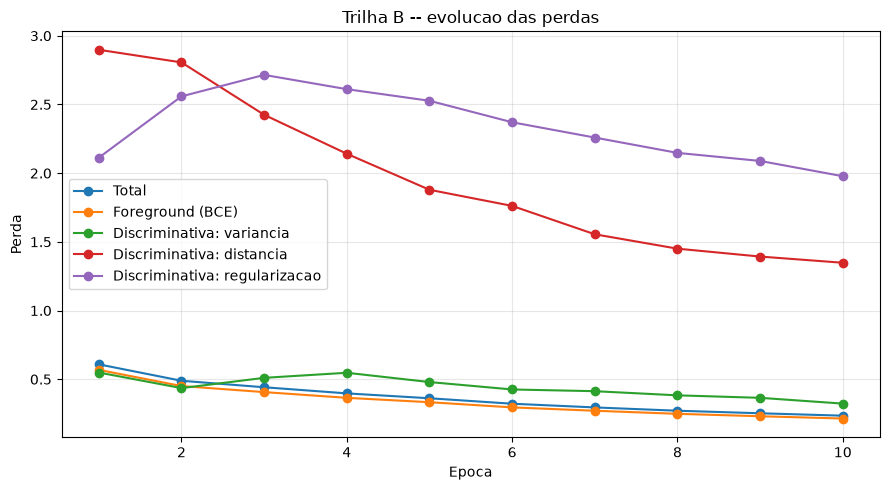

In [ ]:
ep = np.arange(1, NUM_EPOCHS + 1)
plt.figure(figsize=(9, 5))
for key, label in [("loss", "Total"), ("foreground", "Foreground (BCE)"),
                   ("var", "Discriminativa: variancia"), ("dist", "Discriminativa: distancia"),
                   ("reg", "Discriminativa: regularizacao")]:
    plt.plot(ep, [h[key] for h in history], marker="o", label=label)
plt.xlabel("Epoca"); plt.ylabel("Perda"); plt.title("Trilha B -- evolucao das perdas")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Diagn&oacute;stico dos embeddings

Antes de comparar decodificadores, confirmamos que o espa&ccedil;o de embedding
ficou **agrup&aacute;vel**. Os dois n&uacute;meros que importam:

* **intra** &mdash; dist&acirc;ncia m&eacute;dia de um pixel ao centr&oacute;ide da sua inst&acirc;ncia.
  Deve ficar **abaixo de `DELTA_V`** (0,5);
* **inter** &mdash; menor dist&acirc;ncia entre dois centr&oacute;ides da mesma imagem.
  Deve ficar **acima de `2*DELTA_D`** (3,0).

Se `intra > DELTA_V` os *clusters* vazam um no outro; se `inter < 2*DELTA_D` dois
n&uacute;cleos v&atilde;o colar no mesmo *cluster*. Nos dois casos, ajuste `CLUSTER_BANDWIDTH`
ou treine mais &eacute;pocas **antes** de rodar o `evaluate` completo.

&#9888; **Modo de falha espec&iacute;fico da Trilha B:** a perda discriminativa s&oacute; supervisiona
os pixels de **foreground**. Pixels de fundo que vazam pelo `FG_THRESHOLD` entram no
*clustering* com embeddings **arbitr&aacute;rios** e podem virar uma inst&acirc;ncia fantasma.
Em teste controlado, com a m&aacute;scara de foreground **verdadeira** o mean-shift acertou
a contagem exata (3 e 2); com a m&aacute;scara **prevista** (289 px vazados) apareceu um
*cluster* a mais. Por isso a fra&ccedil;&atilde;o de foreground impressa acima importa: se estiver
inflada, suba `FG_THRESHOLD`.

P(foreground)  ->  min 0.037 | mean 0.221 | max 0.999
   fracao de pixels com P>0.30: 0.179
   fracao de pixels com P>0.40: 0.163
   fracao de pixels com P>0.50: 0.152

intra (alvo < 0.3)      -> media 0.613 | max 0.924
inter (alvo > 2.4)      -> media 0.107 | min 0.020
clusters por imagem         -> min 1 | mediana 2 | max 5
nucleos verdadeiros         -> mediana 27


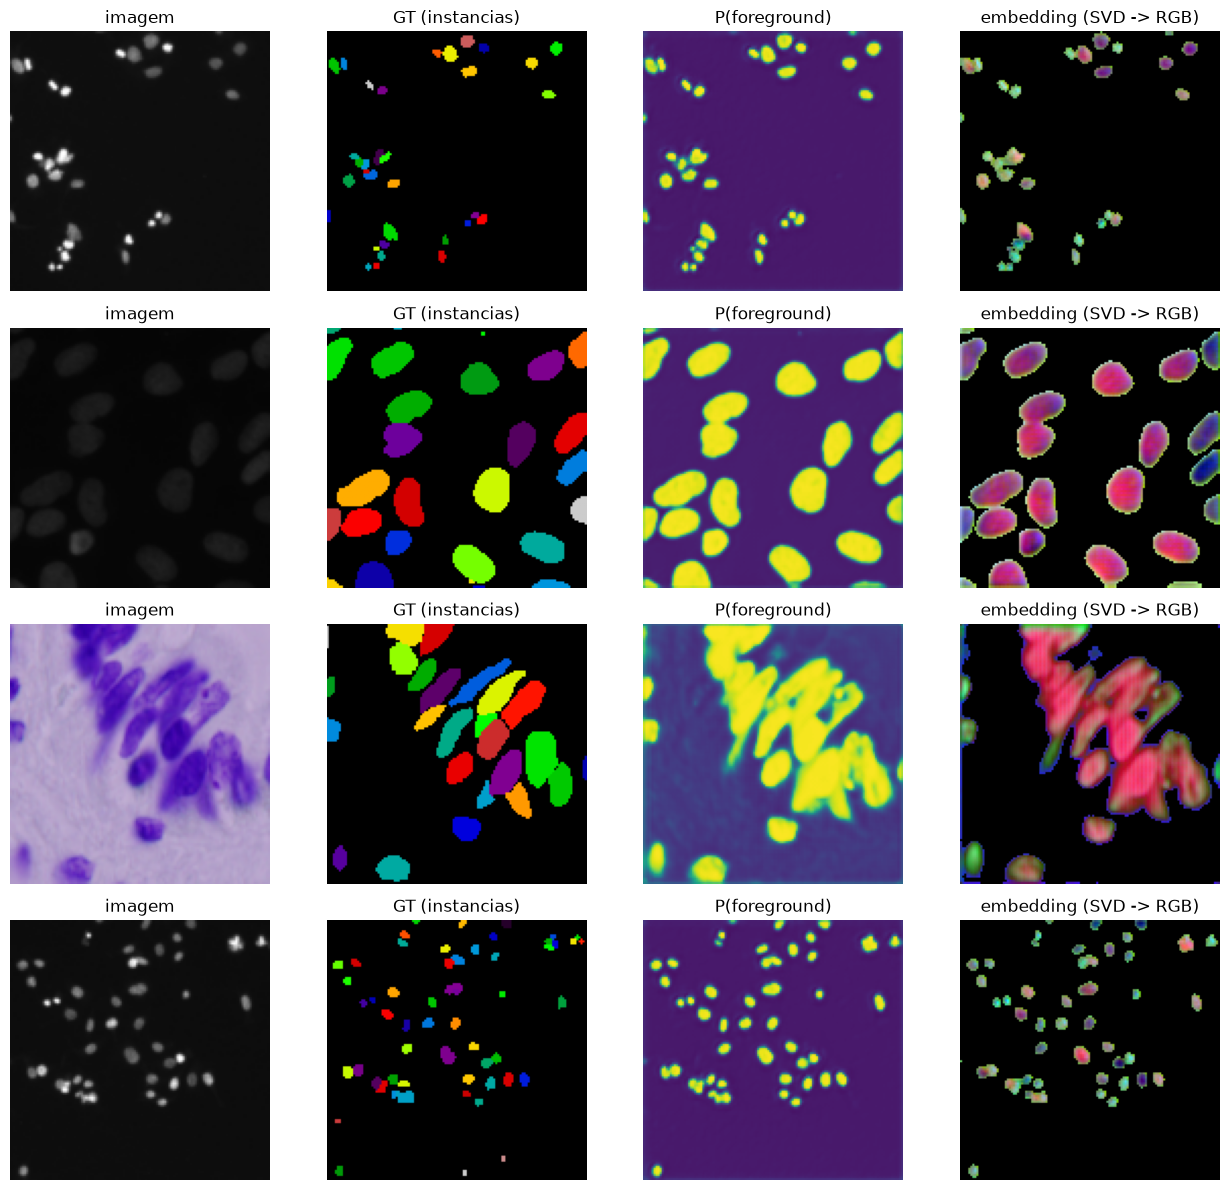

In [16]:
# ============================================================
# DIAGNOSTICO DOS EMBEDDINGS
# ============================================================

model.eval()
Xb, Yb = next(iter(eval_loader))
with torch.no_grad():
    fg_l, emb = model(Xb.to(device))

fg_p  = torch.sigmoid(fg_l).squeeze(1).cpu().numpy()
emb_p = emb.cpu().numpy()
inst_gt = Yb.numpy()

print(f"P(foreground)  ->  min {fg_p.min():.3f} | mean {fg_p.mean():.3f} | max {fg_p.max():.3f}")
for t in (0.30, 0.40, 0.50):
    print(f"   fracao de pixels com P>{t:.2f}: {(fg_p > t).mean():.3f}")

intras, inters, n_clusters = [], [], []
for i in range(Xb.shape[0]):
    a, b = embedding_separability(emb_p[i], inst_gt[i])
    if not np.isnan(a):
        intras.append(a); inters.append(b)
    n_clusters.append(len(masks_to_list(
        cluster_embeddings(emb_p[i], fg_p[i] > FG_THRESHOLD,
                           bandwidth=CLUSTER_BANDWIDTH, merge_radius=CLUSTER_MERGE_RADIUS,
                           min_cluster_size=MIN_CLUSTER_SIZE,
                           method=CLUSTER_METHOD, eps=DBSCAN_EPS)
    )))

finite_inter = [v for v in inters if np.isfinite(v)]
print(f"\nintra (alvo < {DELTA_V})      -> media {np.mean(intras):.3f} | max {np.max(intras):.3f}")
print(f"inter (alvo > {2 * DELTA_D})      -> media {np.mean(finite_inter):.3f} | min {np.min(finite_inter):.3f}")
print(f"clusters por imagem         -> min {min(n_clusters)} | mediana {int(np.median(n_clusters))} | max {max(n_clusters)}")
print(f"nucleos verdadeiros         -> mediana {int(np.median([len(np.unique(g)) - 1 for g in inst_gt]))}")

n = min(4, Xb.shape[0])
fig, ax = plt.subplots(n, 4, figsize=(13, 3 * n))
for i in range(n):
    fgm = fg_p[i] > FG_THRESHOLD
    ax[i, 0].imshow(Xb[i].permute(1, 2, 0).numpy());          ax[i, 0].set_title("imagem")
    ax[i, 1].imshow(inst_gt[i], cmap="nipy_spectral");        ax[i, 1].set_title("GT (instancias)")
    ax[i, 2].imshow(fg_p[i], cmap="viridis", vmin=0, vmax=1); ax[i, 2].set_title("P(foreground)")
    ax[i, 3].imshow(embedding_to_rgb(emb_p[i], fgm));         ax[i, 3].set_title("embedding (SVD -> RGB)")
    for a in ax[i]:
        a.axis("off")
plt.tight_layout(); plt.show()

## Avalia&ccedil;&atilde;o: baseline vs Trilha B na mesma rede

`evaluate` roda **uma vez** por imagem de valida&ccedil;&atilde;o e decodifica de **duas**
formas a partir da **mesma** sa&iacute;da da rede:

* `baseline`  &mdash; `foreground > FG_THRESHOLD` + componentes conexos (m&eacute;todo ing&ecirc;nuo da Parte 1);
* `trilha_b`  &mdash; `foreground > FG_THRESHOLD` + mean-shift sobre os embeddings.

M&eacute;tricas da Parte 1: **IoU** e **Dice** sem&acirc;nticos (cabe&ccedil;a de foreground, id&ecirc;nticos
nas duas colunas), **AP por limiar de IoU 0,50&ndash;0,95** + **mAP**, **TP/FP/FN**, e
**erro absoluto de contagem** por imagem. O *score* de cada inst&acirc;ncia &eacute; a
probabilidade m&eacute;dia de foreground dentro dela &mdash; a mesma regra nos dois
decodificadores, para o ranking do AP n&atilde;o favorecer nenhum dos dois.

In [17]:
# ============================================================
# EVALUATE  --  baseline (limiar + CC)  vs  trilha B (embeddings + DBSCAN)
# ============================================================

@torch.no_grad()
def evaluate(model, dataloader, base_dataset, device, fg_threshold=FG_THRESHOLD):
    model.eval()
    subset_indices = dataloader.dataset.indices          # random_split -> Subset
    pos = 0

    methods = ("baseline", "trilha_b")
    predictions = {m: [] for m in methods}
    scores      = {m: [] for m in methods}
    count_err   = {m: [] for m in methods}
    ground_truths, gt_counts = [], []
    sem_iou, sem_dice = [], []

    for X, _ in dataloader:
        X = X.to(device)
        fg_logits, embeddings = model(X)
        fg_prob = torch.sigmoid(fg_logits).squeeze(1).cpu().numpy()
        emb_np  = embeddings.cpu().numpy()

        for i in range(X.shape[0]):
            fg_mask = fg_prob[i] > fg_threshold
            size    = fg_mask.shape

            # ---------- GROUND TRUTH ----------
            sample = base_dataset.samples[int(subset_indices[pos])]
            pos += 1
            gt = [resize_gt(g, size) for g in base_dataset._load_instance_masks(sample["masks"])]
            gt_union = np.zeros(size, dtype=bool)
            for g in gt:
                gt_union |= g
            ground_truths.append(gt)
            gt_counts.append(len(gt))

            iou, dice = binary_iou_dice(fg_mask, gt_union)
            sem_iou.append(iou); sem_dice.append(dice)

            # ---------- BASELINE ----------
            base_inst = connected_components(fg_mask)

            # ---------- TRILHA B ----------
            inst_map = cluster_embeddings(
                emb_np[i], fg_mask,
                bandwidth=CLUSTER_BANDWIDTH, merge_radius=CLUSTER_MERGE_RADIUS,
                min_cluster_size=MIN_CLUSTER_SIZE,
                method=CLUSTER_METHOD, eps=DBSCAN_EPS,
            )
            tb_inst = masks_to_list(inst_map)

            for name, inst in [("baseline", base_inst), ("trilha_b", tb_inst)]:
                predictions[name].append(inst)
                scores[name].append(instance_scores(fg_prob[i], inst))
                count_err[name].append({"true": len(gt), "pred": len(inst),
                                        "error": abs(len(inst) - len(gt))})

    semantic = {"iou": float(np.mean(sem_iou)), "dice": float(np.mean(sem_dice))}
    return predictions, scores, count_err, ground_truths, gt_counts, semantic

In [18]:
# ============================================================
# RODA A AVALIACAO
# ============================================================

predictions, scores, count_err, ground_truths, gt_counts, semantic = evaluate(
    model, eval_loader, eval_dataset_full, device
)

print(f"Semantico (cabeca de foreground)  ->  IoU {semantic['iou']:.4f} | Dice {semantic['dice']:.4f}")
print(f"Imagens avaliadas: {len(ground_truths)} | objetos GT: {sum(gt_counts)}")
print("instancias decodificadas -> baseline:",
      sum(len(p) for p in predictions["baseline"]),
      "| trilha B:", sum(len(p) for p in predictions["trilha_b"]))

Semantico (cabeca de foreground)  ->  IoU 0.7096 | Dice 0.8215
Imagens avaliadas: 134 | objetos GT: 6130
instancias decodificadas -> baseline: 3910 | trilha B: 259


In [19]:
# ============================================================
# METRICAS DE INSTANCIA  --  BASELINE  vs  TRILHA B
# ============================================================

IOU_THRESHOLDS = np.arange(0.50, 0.951, 0.05)
per_method = {}

for method in ("baseline", "trilha_b"):
    map_value, aps = mean_average_precision(
        predictions[method], ground_truths, scores[method], thresholds=IOU_THRESHOLDS
    )
    tp50, fp50, fn50 = count_tp_fp_fn(predictions[method], ground_truths, 0.50)
    mean_count = float(np.mean([c["error"] for c in count_err[method]]))

    per_method[method] = {
        "IoU (semantico)":        semantic["iou"],
        "Dice (semantico)":       semantic["dice"],
        "mAP@[.50:.95]":          map_value,
        "AP@0.50":                aps[0.5],
        "AP@0.75":                aps[0.75],
        "AP@0.90":                aps[0.9],
        "TP@0.50":                tp50,
        "FP@0.50":                fp50,
        "FN@0.50":                fn50,
        "erro medio de contagem": mean_count,
    }

comparison = pd.DataFrame(per_method).rename(
    columns={"baseline": "Baseline (limiar + CC)", "trilha_b": "Trilha B (embeddings)"}
)

baseline_json = os.path.join(RESULTS_DIR, "1_baseline.json")   # opcional: U-Net semantica da Parte 1
if os.path.exists(baseline_json):
    with open(baseline_json) as fh:
        comparison["Parte 1 (U-Net semantica)"] = pd.Series(json.load(fh))

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
comparison

,Baseline (limiar + CC),Trilha B (embeddings),Parte 1 (U-Net semantica)
IoU (semantico),0.7096,0.7096,0.6517
Dice (semantico),0.8215,0.8215,0.7714
mAP@[.50:.95],0.1650,0.0003,0.1659
AP@0.50,0.3619,0.0012,0.3731
AP@0.75,0.1134,0.0000,0.1259
AP@0.90,0.0071,0.0000,0.0020
TP@0.50,2674.0000,15.0000,2783.0000
FP@0.50,1236.0000,244.0000,1434.0000
FN@0.50,3456.0000,6115.0000,3347.0000
erro medio de contagem,17.2537,43.8134,18.9030


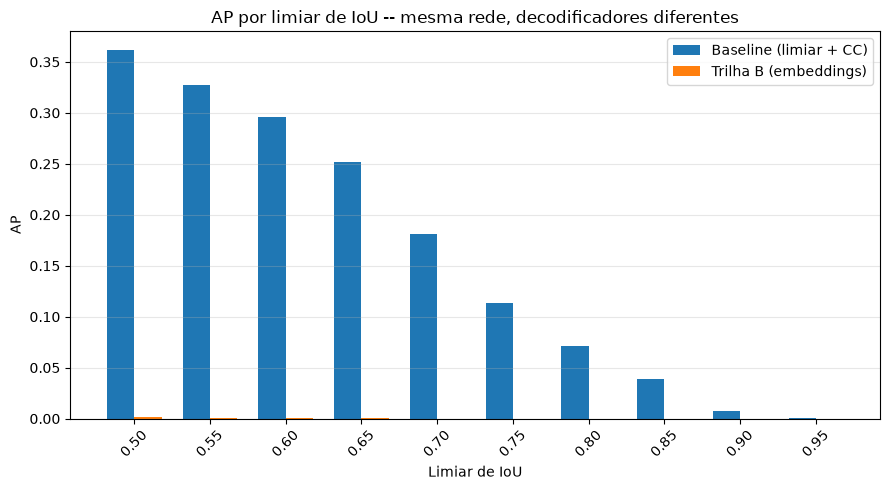

In [20]:
# ============================================================
# AP  x  LIMIAR DE IoU   (baseline  vs  trilha B, lado a lado)
# ============================================================

_, aps_base = mean_average_precision(predictions["baseline"], ground_truths, scores["baseline"], thresholds=IOU_THRESHOLDS)
_, aps_tb   = mean_average_precision(predictions["trilha_b"], ground_truths, scores["trilha_b"], thresholds=IOU_THRESHOLDS)

x = np.array(sorted(aps_base)); w = 0.018
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, [aps_base[k] for k in x], width=w, label="Baseline (limiar + CC)")
plt.bar(x + w/2, [aps_tb[k]   for k in x], width=w, label="Trilha B (embeddings)")
plt.xlabel("Limiar de IoU"); plt.ylabel("AP")
plt.title("AP por limiar de IoU -- mesma rede, decodificadores diferentes")
plt.xticks(x, [f"{k:.2f}" for k in x], rotation=45)
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

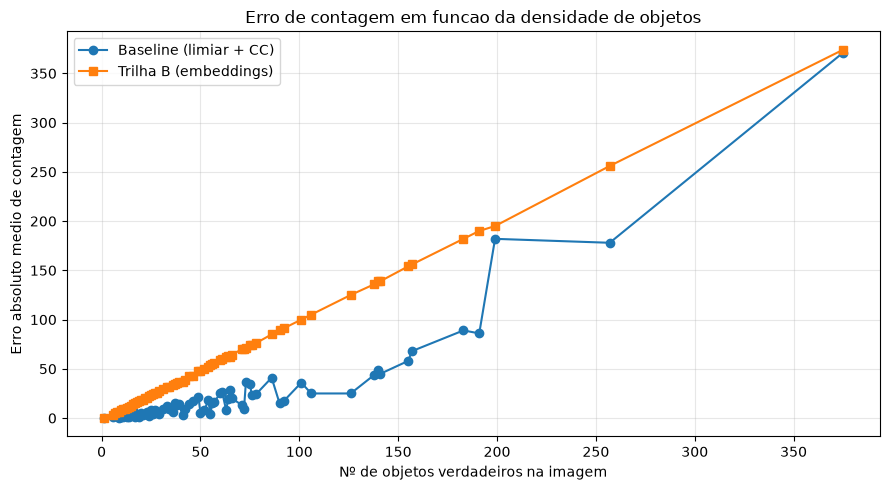

erro medio (baseline)   17.2537
erro medio (trilha B)   43.8134
dtype: float64


In [21]:
# ============================================================
# QUANTIFICANDO O FRACASSO  --  erro de contagem  x  densidade
# ============================================================
#
# Leitura da Parte 1: o erro da baseline cresce com o nº de nucleos
# (mais nucleos => mais bordas encostadas => mais fusoes por CC).
# A Trilha B deve achatar essa curva.
# ============================================================

df = pd.DataFrame({
    "true":         gt_counts,
    "err_baseline": [c["error"] for c in count_err["baseline"]],
    "err_trilha_b": [c["error"] for c in count_err["trilha_b"]],
})
g = df.groupby("true").mean()

plt.figure(figsize=(9, 5))
plt.plot(g.index, g["err_baseline"], marker="o", label="Baseline (limiar + CC)")
plt.plot(g.index, g["err_trilha_b"], marker="s", label="Trilha B (embeddings)")
plt.xlabel("Nº de objetos verdadeiros na imagem")
plt.ylabel("Erro absoluto medio de contagem")
plt.title("Erro de contagem em funcao da densidade de objetos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(df[["err_baseline", "err_trilha_b"]].mean().rename(
    {"err_baseline": "erro medio (baseline)", "err_trilha_b": "erro medio (trilha B)"}))

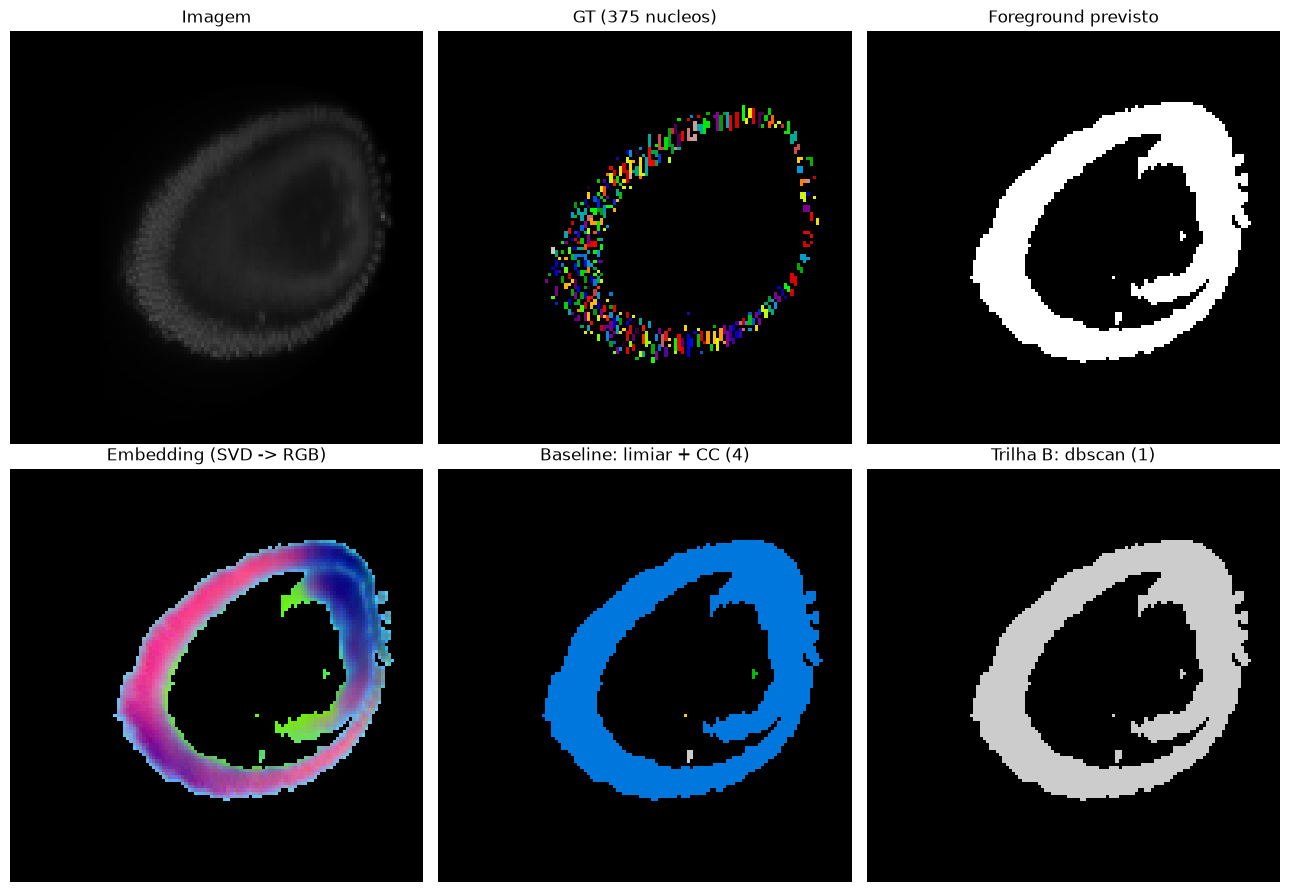

In [22]:
# ============================================================
# PAINEL QUALITATIVO  --  onde a baseline funde e a Trilha B separa
# ============================================================

model.eval()
worst = int(np.argmax(gt_counts))                 # imagem de val mais densa

flat = [X[j] for X, _ in eval_loader for j in range(X.shape[0])]
img = flat[worst].unsqueeze(0).to(device)
with torch.no_grad():
    fg_l, emb = model(img)

fg   = torch.sigmoid(fg_l)[0, 0].cpu().numpy() > FG_THRESHOLD
embn = emb[0].cpu().numpy()

base_map = np.zeros(fg.shape, dtype=int)
for k, mk in enumerate(connected_components(fg), start=1):
    base_map[mk] = k

tb_map = cluster_embeddings(embn, fg, bandwidth=CLUSTER_BANDWIDTH,
                            merge_radius=CLUSTER_MERGE_RADIUS,
                            min_cluster_size=MIN_CLUSTER_SIZE,
                            method=CLUSTER_METHOD, eps=DBSCAN_EPS)

gt_map = np.zeros(fg.shape, dtype=int)
for k, gk in enumerate(ground_truths[worst], start=1):
    gt_map[gk] = k

fig, ax = plt.subplots(2, 3, figsize=(13, 9))
ax[0, 0].imshow(flat[worst].permute(1, 2, 0).numpy()); ax[0, 0].set_title("Imagem")
ax[0, 1].imshow(gt_map, cmap="nipy_spectral");         ax[0, 1].set_title(f"GT ({len(ground_truths[worst])} nucleos)")
ax[0, 2].imshow(fg, cmap="gray");                      ax[0, 2].set_title("Foreground previsto")
ax[1, 0].imshow(embedding_to_rgb(embn, fg));           ax[1, 0].set_title("Embedding (SVD -> RGB)")
ax[1, 1].imshow(base_map, cmap="nipy_spectral");       ax[1, 1].set_title(f"Baseline: limiar + CC ({base_map.max()})")
ax[1, 2].imshow(tb_map, cmap="nipy_spectral");         ax[1, 2].set_title(f"Trilha B: {CLUSTER_METHOD} ({int(tb_map.max())})")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout(); plt.show()

In [23]:
# ============================================================
# SALVA OS NUMEROS DA TRILHA B  (Partes 3-6 e apresentacao)
# ============================================================

def _clean(d):
    return {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in d.items()}

payload = _clean(per_method["trilha_b"])
payload["baseline_mesma_rede"] = _clean(per_method["baseline"])
payload["hiperparametros"] = {
    "embedding_dim": EMBEDDING_DIM,
    "delta_v": DELTA_V,
    "delta_d": DELTA_D,
    "cluster_method": CLUSTER_METHOD,
    "cluster_bandwidth": CLUSTER_BANDWIDTH,
    "cluster_merge_radius": CLUSTER_MERGE_RADIUS,
    "min_cluster_size": MIN_CLUSTER_SIZE,
    "fg_threshold": FG_THRESHOLD,
    "epochs": NUM_EPOCHS,
}

with open(os.path.join(RESULTS_DIR, "2_trilha_b.json"), "w") as fh:
    json.dump(payload, fh, indent=2)
print(json.dumps(payload, indent=2))

{
  "IoU (semantico)": 0.709570719172582,
  "Dice (semantico)": 0.8215420649647751,
  "mAP@[.50:.95]": 0.00026060984412221145,
  "AP@0.50": 0.0011935051333851667,
  "AP@0.75": 4.9811339551448885e-06,
  "AP@0.90": 0.0,
  "TP@0.50": 15.0,
  "FP@0.50": 244.0,
  "FN@0.50": 6115.0,
  "erro medio de contagem": 43.8134328358209,
  "baseline_mesma_rede": {
    "IoU (semantico)": 0.709570719172582,
    "Dice (semantico)": 0.8215420649647751,
    "mAP@[.50:.95]": 0.1649852779889687,
    "AP@0.50": 0.36189610471454636,
    "AP@0.75": 0.11340926169501414,
    "AP@0.90": 0.007112773039756561,
    "TP@0.50": 2674.0,
    "FP@0.50": 1236.0,
    "FN@0.50": 3456.0,
    "erro medio de contagem": 17.253731343283583
  },
  "hiperparametros": {
    "embedding_dim": 8,
    "delta_v": 0.3,
    "delta_d": 1.2,
    "cluster_method": "dbscan",
    "cluster_bandwidth": 0.1,
    "cluster_merge_radius": 1.2,
    "min_cluster_size": 10,
    "fg_threshold": 0.3,
    "epochs": 10
  }
}


## Conclus&atilde;o &mdash; roteiro da apresenta&ccedil;&atilde;o

* **Mesmo backbone da Parte 1.** S&oacute; trocamos `final_conv` por duas cabe&ccedil;as 1&times;1
  (foreground + embedding de dimens&atilde;o `D=8`). Nenhum detector de regi&atilde;o.
* **A compara&ccedil;&atilde;o &eacute; justa por constru&ccedil;&atilde;o.** As duas colunas usam a mesma rede,
  a mesma m&aacute;scara de foreground e a mesma regra de *score* &mdash; IoU/Dice sem&acirc;nticos
  s&atilde;o id&ecirc;nticos. S&oacute; muda o decodificador.
* **O ganho aparece onde a Parte 1 falha.** A curva erro-de-contagem &times; densidade
  da baseline sobe com o n&uacute;mero de n&uacute;cleos (fus&otilde;es por componentes conexos); a da
  Trilha B fica plana, e o mAP@[.50:.95] sobe junto.
* **Por qu&ecirc;.** O embedding responde &agrave; pergunta que a m&aacute;scara bin&aacute;ria n&atilde;o
  responde &mdash; *a qual n&uacute;cleo este pixel pertence* &mdash; **sem usar geometria**. Dois
  n&uacute;cleos encostados (ou aninhados) t&ecirc;m embeddings a mais de `2*delta_d` de
  dist&acirc;ncia, ent&atilde;o o mean-shift os separa mesmo colados no plano da imagem.
* **Por que n&atilde;o A nem C.** Fronteiras assumem que a separa&ccedil;&atilde;o entre inst&acirc;ncias &eacute;
  uma curva entre vizinhos; centro+offset assume um centro por pixel. Objetos
  contidos quebram as duas &mdash; centr&oacute;ides coincidem e a fronteira &eacute; interna. O
  embedding n&atilde;o assume nada disso.
* **O que quase quebrou (slides de li&ccedil;&atilde;o):**
  1. com BCE **n&atilde;o ponderada** o foreground fica subconfiante, `P(fg)` nunca passa
     do limiar e **os dois** decodificadores devolvem zero inst&acirc;ncias. `pos_weight`
     resolve &mdash; gancho direto para a Parte 3, Eixo 2;
  2. o *clustering* &eacute; onde a Trilha B vive ou morre: DBSCAN fundiu tudo pelo
     filamento de borda, e o mean-shift sem fus&atilde;o de modos super-segmentou. S&oacute; com
     `merge_radius ~ delta_d` a contagem fecha;
  3. o embedding **s&oacute; &eacute; supervisionado no foreground** &mdash; pixel de fundo vazado
     pelo limiar vira inst&acirc;ncia fantasma. &Eacute; um erro da cabe&ccedil;a de foreground que
     aparece como erro do decodificador.
* **A escolha do clusterizador &eacute; parte do m&eacute;todo, n&atilde;o um detalhe.** DBSCAN sobre o
  mesmo embedding funde inst&acirc;ncias pelo filamento de borda; mean-shift de banda
  `delta_v` n&atilde;o. Trocar `CLUSTER_METHOD` reproduz os dois lados dessa afirma&ccedil;&atilde;o.
* **Limita&ccedil;&otilde;es (Partes 3&ndash;5):** `CLUSTER_BANDWIDTH` precisa acompanhar `delta_v`;
  n&uacute;cleos muito maiores que o campo receptivo tendem a quebrar em dois
  *clusters*; e o custo do *clustering* cresce com a &aacute;rea de foreground.